# XOR 신경망 가중치 변화 관찰

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# ====== 1. 데이터 ======
X = torch.tensor([[0.,0.],
                  [0.,1.],
                  [1.,0.],
                  [1.,1.]], dtype=torch.float32)
y = torch.tensor([[0.],
                  [1.],
                  [1.],
                  [0.]], dtype=torch.float32)


# ====== 2. 모델 정의 ======
class XORNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 2)    # 2 → 2
        self.act1 = nn.Tanh()         # 비선형성
        self.fc2 = nn.Linear(2, 1)    # 2 → 1
        self.act2 = nn.Sigmoid()

    def forward(self, x):
        h = self.act1(self.fc1(x))   # 은닉층
        out = self.act2(self.fc2(h)) # 출력층
        return out, h

model = XORNet()


# ====== 3. 손실함수 & 옵티마이저 ======
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

# ====== 4. 학습 기록 저장 공간 ======
log = {
    "epoch": [],
    "W1": [], "b1": [],
    "W2": [], "b2": [],
    "hidden": [],       # 은닉층 출력
    "y_hat": [],        # 예측값
    "loss": [],
}


# ====== 5. 학습 ======
epochs = 5000
for epoch in range(epochs):

    # ===== Forward =====
    y_hat, hidden = model(X)
    loss = criterion(y_hat, y)

    # ===== Backward =====
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # ===== 학습 기록 저장 =====
    if epoch % 100 == 0:      # 100epoch마다 기록 (원하면 1로 바꿔도 됨)
        W1 = model.fc1.weight.data.clone()
        b1 = model.fc1.bias.data.clone()
        W2 = model.fc2.weight.data.clone()
        b2 = model.fc2.bias.data.clone()

        log["epoch"].append(epoch)
        log["W1"].append(W1)
        log["b1"].append(b1)
        log["W2"].append(W2)
        log["b2"].append(b2)
        log["hidden"].append(hidden.data.clone())
        log["y_hat"].append(y_hat.data.clone())
        log["loss"].append(loss.item())

        print(f"Epoch {epoch}")
        print(" W1:", W1)
        print(" b1:", b1)
        print(" W2:", W2)
        print(" b2:", b2)
        print(" Hidden Layer Output:\n", hidden.data)
        print(" y_hat:\n", y_hat.data)
        print(" Loss:", loss.item())
        print("-"*40)


# ====== 6. 마지막 결과 ======
print("\nFinal Prediction:")
final_y, final_h = model(X)
print("Input  :", X)
print("Hidden :", final_h.data)
print("Output :", final_y.data)
print("Loss   :", criterion(final_y, y).item())


## 가중치변화 그래프로 관찰

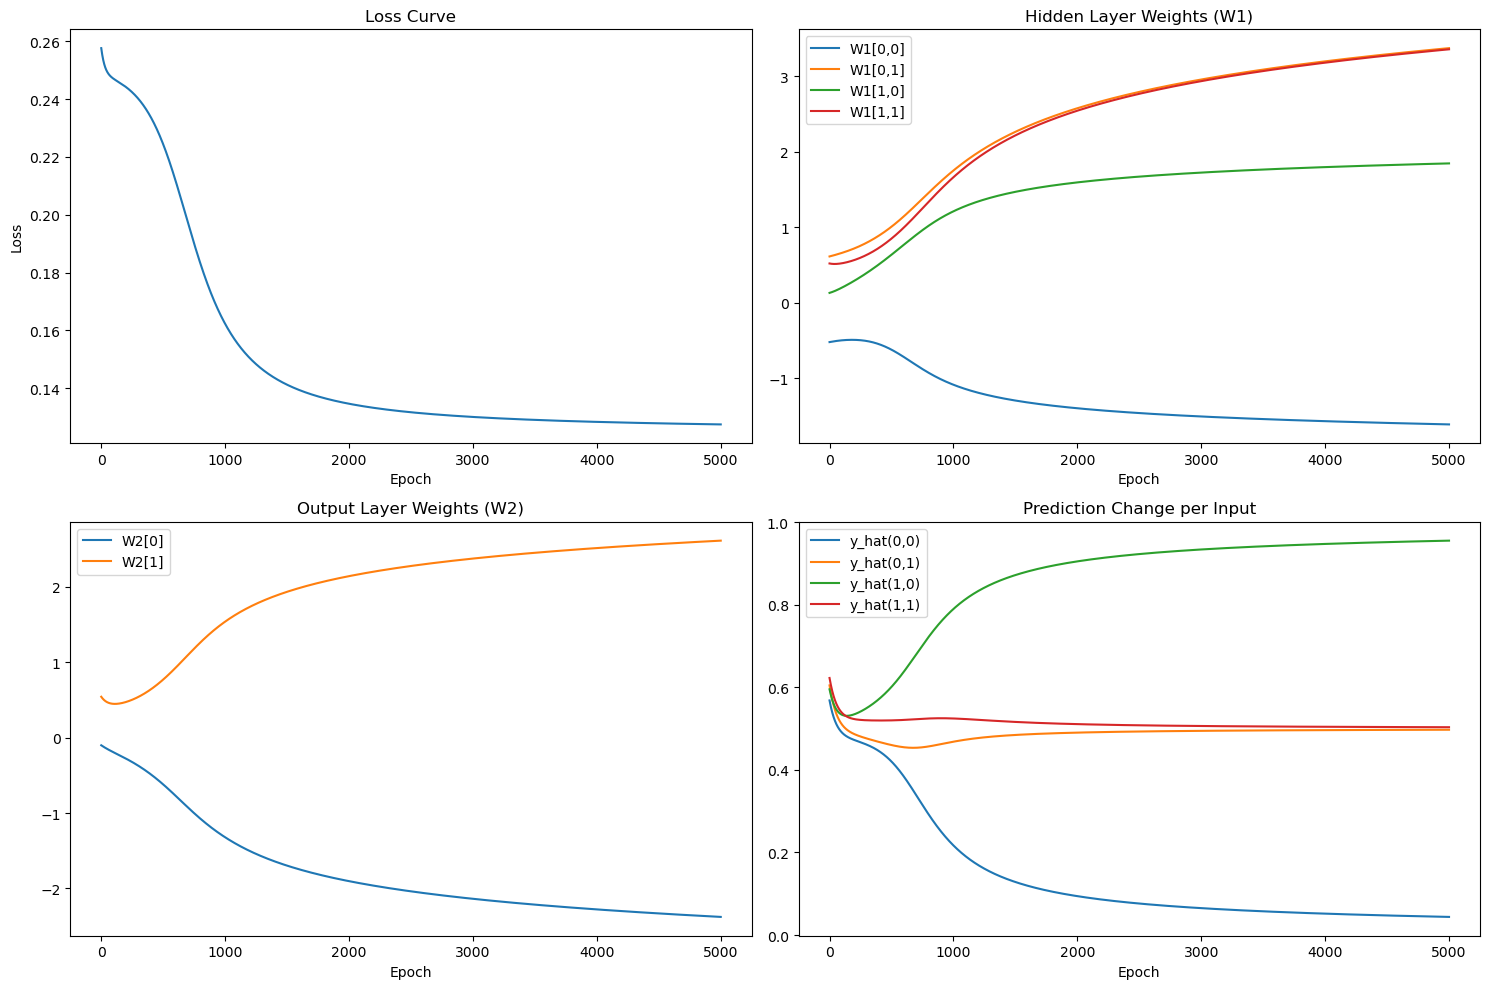

Final Output:
 tensor([[0.0439],
        [0.4971],
        [0.9549],
        [0.5032]], grad_fn=<SigmoidBackward0>)
Final Hidden:
 tensor([[ 0.8330, -0.3312],
        [ 0.9998,  0.9952],
        [-0.3885,  0.9056],
        [ 0.9947,  0.9999]], grad_fn=<TanhBackward0>)
Final Loss: 0.12752337753772736


'\n풀배치수로 에포크수가 네개의 입력값이 모두들어가서 몇번학습됐는지 수와 같다.\n'

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# ====== 1. 데이터 ======
X = torch.tensor([[0.,0.],
                  [0.,1.],
                  [1.,0.],
                  [1.,1.]], dtype=torch.float32)
y = torch.tensor([[0.],
                  [1.],
                  [1.],
                  [0.]], dtype=torch.float32)


# ====== 2. 모델 ======
class XORNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 2)
        self.act1 = nn.Tanh()
        self.fc2 = nn.Linear(2, 1)
        self.act2 = nn.Sigmoid()

    def forward(self, x):
        h = self.act1(self.fc1(x))
        out = self.act2(self.fc2(h))
        return out, h

model = XORNet()


# ====== 3. 손실 & 옵티마이저 ======
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

# ====== 4. 기록 ======
epochs = 5000
log_loss = []
log_W1 = []
log_W2 = []
log_yhat = []
log_hidden = []

# ====== 5. 학습 ======
for epoch in range(epochs):

    y_hat, hidden = model(X)
    loss = criterion(y_hat, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # 기록 (매 epoch 저장)
    log_loss.append(loss.item())
    log_W1.append(model.fc1.weight.data.clone().numpy())
    log_W2.append(model.fc2.weight.data.clone().numpy())
    log_yhat.append(y_hat.data.clone().numpy())
    log_hidden.append(hidden.data.clone().numpy())


# ====== 6. 시각화 ======
plt.figure(figsize=(15, 10))

# ---- (1) Loss 그래프 ----
plt.subplot(2, 2, 1)
plt.plot(log_loss)
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

# ---- (2) W1 변화 ----
W1_arr = torch.tensor(log_W1).numpy()  # (epochs, 2, 2)
plt.subplot(2, 2, 2)
plt.plot(W1_arr[:,0,0], label="W1[0,0]")
plt.plot(W1_arr[:,0,1], label="W1[0,1]")
plt.plot(W1_arr[:,1,0], label="W1[1,0]")
plt.plot(W1_arr[:,1,1], label="W1[1,1]")
plt.title("Hidden Layer Weights (W1)")
plt.xlabel("Epoch")
plt.legend()

# ---- (3) W2 변화 ----
W2_arr = torch.tensor(log_W2).numpy()  # (epochs, 1, 2)
plt.subplot(2, 2, 3)
plt.plot(W2_arr[:,0,0], label="W2[0]")
plt.plot(W2_arr[:,0,1], label="W2[1]")
plt.title("Output Layer Weights (W2)")
plt.xlabel("Epoch")
plt.legend()

# ---- (4) 출력값 변화 ----
yhat_arr = torch.tensor(log_yhat).numpy()  # (epochs, 4, 1)
plt.subplot(2, 2, 4)
plt.plot(yhat_arr[:,0,0], label="y_hat(0,0)")
plt.plot(yhat_arr[:,1,0], label="y_hat(0,1)")
plt.plot(yhat_arr[:,2,0], label="y_hat(1,0)")
plt.plot(yhat_arr[:,3,0], label="y_hat(1,1)")
plt.title("Prediction Change per Input")
plt.xlabel("Epoch")
plt.legend()

plt.tight_layout()
plt.show()


# ====== 7. 최종결과 ======
final_y, final_h = model(X)
print("Final Output:\n", final_y)
print("Final Hidden:\n", final_h)
print("Final Loss:", criterion(final_y, y).item())

'''
풀배치수로 에포크수가 네개의 입력값이 모두들어가서 몇번학습됐는지 수와 같다.
'''

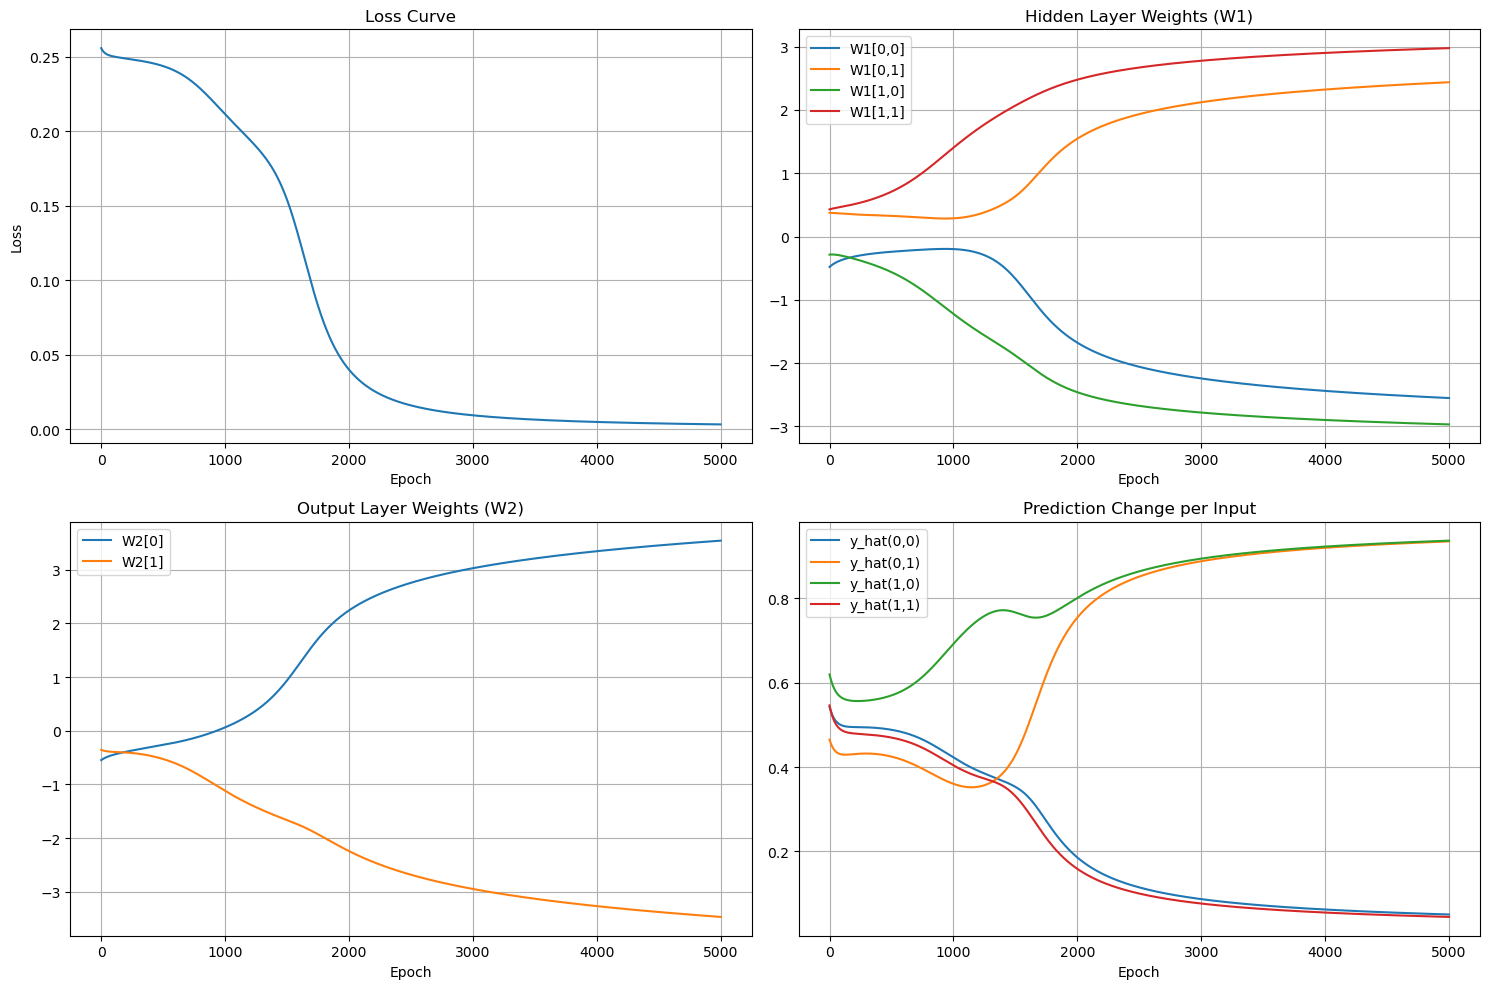

Final Output:
 tensor([[0.0506],
        [0.9347],
        [0.9365],
        [0.0448]], grad_fn=<SigmoidBackward0>)
Final Hidden:
 tensor([[-0.8184,  0.9002],
        [ 0.8581,  0.9997],
        [-0.9988, -0.9042],
        [-0.8526,  0.9018]], grad_fn=<TanhBackward0>)
Final Loss: 0.003214710857719183


In [10]:
# 그래프에 격자추가

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# ====== 1. 데이터 ======
X = torch.tensor([[0.,0.],
                  [0.,1.],
                  [1.,0.],
                  [1.,1.]], dtype=torch.float32)
y = torch.tensor([[0.],
                  [1.],
                  [1.],
                  [0.]], dtype=torch.float32)


# ====== 2. 모델 ======
class XORNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 2)
        self.act1 = nn.Tanh()
        self.fc2 = nn.Linear(2, 1)
        self.act2 = nn.Sigmoid()

    def forward(self, x):
        h = self.act1(self.fc1(x))
        out = self.act2(self.fc2(h))
        return out, h

model = XORNet()


# ====== 3. 손실 & 옵티마이저 ======
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

# ====== 4. 기록 ======
epochs = 5000
log_loss = []
log_W1 = []
log_W2 = []
log_yhat = []
log_hidden = []

# ====== 5. 학습 ======
for epoch in range(epochs):

    y_hat, hidden = model(X)
    loss = criterion(y_hat, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # 기록 (매 epoch 저장)
    log_loss.append(loss.item())
    log_W1.append(model.fc1.weight.data.clone().numpy())
    log_W2.append(model.fc2.weight.data.clone().numpy())
    log_yhat.append(y_hat.data.clone().numpy())
    log_hidden.append(hidden.data.clone().numpy())


# ====== 6. 시각화 ======
plt.figure(figsize=(15, 10))

# ---- (1) Loss 그래프 ----
plt.subplot(2, 2, 1)
plt.plot(log_loss)
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)   # ← 격자 추가

# ---- (2) W1 변화 ----
W1_arr = torch.tensor(log_W1).numpy()
plt.subplot(2, 2, 2)
plt.plot(W1_arr[:,0,0], label="W1[0,0]")
plt.plot(W1_arr[:,0,1], label="W1[0,1]")
plt.plot(W1_arr[:,1,0], label="W1[1,0]")
plt.plot(W1_arr[:,1,1], label="W1[1,1]")
plt.title("Hidden Layer Weights (W1)")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True)   # ← 격자 추가

# ---- (3) W2 변화 ----
W2_arr = torch.tensor(log_W2).numpy()
plt.subplot(2, 2, 3)
plt.plot(W2_arr[:,0,0], label="W2[0]")
plt.plot(W2_arr[:,0,1], label="W2[1]")
plt.title("Output Layer Weights (W2)")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True)   # ← 격자 추가

# ---- (4) 출력값 변화 ----
yhat_arr = torch.tensor(log_yhat).numpy()
plt.subplot(2, 2, 4)
plt.plot(yhat_arr[:,0,0], label="y_hat(0,0)")
plt.plot(yhat_arr[:,1,0], label="y_hat(0,1)")
plt.plot(yhat_arr[:,2,0], label="y_hat(1,0)")
plt.plot(yhat_arr[:,3,0], label="y_hat(1,1)")
plt.title("Prediction Change per Input")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True)   # ← 격자 추가

plt.tight_layout()
plt.show()


# ====== 7. 최종 결과 ======
final_y, final_h = model(X)
print("Final Output:\n", final_y)
print("Final Hidden:\n", final_h)
print("Final Loss:", criterion(final_y, y).item())


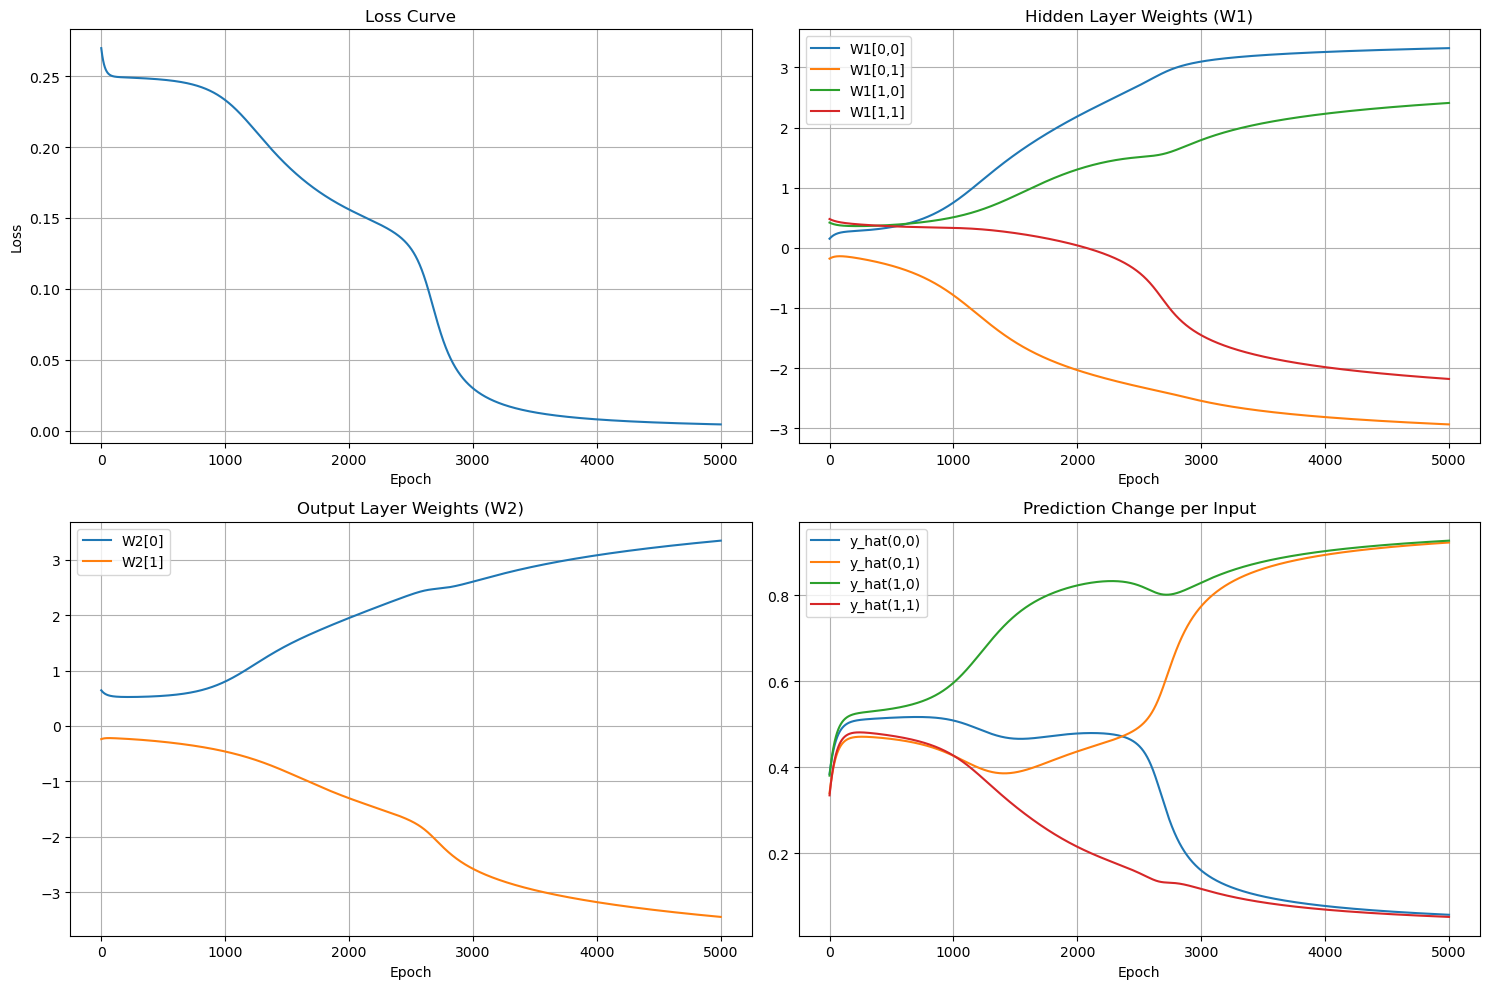

Final Output:
 tensor([[0.0571],
        [0.9229],
        [0.9272],
        [0.0521]], grad_fn=<SigmoidBackward0>)
Final Hidden:
 tensor([[-0.9459,  0.7464],
        [-0.9998, -0.8386],
        [ 0.9105,  0.9977],
        [-0.8867,  0.8318]], grad_fn=<TanhBackward0>)
Final Loss: 0.004307370632886887


In [11]:
# 그래프에 격자추가

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# ====== 1. 데이터 ======
X = torch.tensor([[0.,0.],
                  [0.,1.],
                  [1.,0.],
                  [1.,1.]], dtype=torch.float32)
y = torch.tensor([[0.],
                  [1.],
                  [1.],
                  [0.]], dtype=torch.float32)


# ====== 2. 모델 ======
class XORNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 2)
        self.act1 = nn.Tanh()
        self.fc2 = nn.Linear(2, 1)
        self.act2 = nn.Sigmoid()

    def forward(self, x):
        h = self.act1(self.fc1(x))
        out = self.act2(self.fc2(h))
        return out, h

model = XORNet()


# ====== 3. 손실 & 옵티마이저 ======
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

# ====== 4. 기록 ======
epochs = 5000
log_loss = []
log_W1 = []
log_W2 = []
log_yhat = []
log_hidden = []

# ====== 5. 학습 ======
for epoch in range(epochs):

    y_hat, hidden = model(X)
    loss = criterion(y_hat, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # 기록 (매 epoch 저장)
    log_loss.append(loss.item())
    log_W1.append(model.fc1.weight.data.clone().numpy())
    log_W2.append(model.fc2.weight.data.clone().numpy())
    log_yhat.append(y_hat.data.clone().numpy())
    log_hidden.append(hidden.data.clone().numpy())


# ====== 6. 시각화 ======
plt.figure(figsize=(15, 10))

# ---- (1) Loss 그래프 ----
plt.subplot(2, 2, 1)
plt.plot(log_loss)
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)   # ← 격자 추가

# ---- (2) W1 변화 ----
W1_arr = torch.tensor(log_W1).numpy()
plt.subplot(2, 2, 2)
plt.plot(W1_arr[:,0,0], label="W1[0,0]")
plt.plot(W1_arr[:,0,1], label="W1[0,1]")
plt.plot(W1_arr[:,1,0], label="W1[1,0]")
plt.plot(W1_arr[:,1,1], label="W1[1,1]")
plt.title("Hidden Layer Weights (W1)")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True)   # ← 격자 추가

# ---- (3) W2 변화 ----
W2_arr = torch.tensor(log_W2).numpy()
plt.subplot(2, 2, 3)
plt.plot(W2_arr[:,0,0], label="W2[0]")
plt.plot(W2_arr[:,0,1], label="W2[1]")
plt.title("Output Layer Weights (W2)")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True)   # ← 격자 추가

# ---- (4) 출력값 변화 ----
yhat_arr = torch.tensor(log_yhat).numpy()
plt.subplot(2, 2, 4)
plt.plot(yhat_arr[:,0,0], label="y_hat(0,0)")
plt.plot(yhat_arr[:,1,0], label="y_hat(0,1)")
plt.plot(yhat_arr[:,2,0], label="y_hat(1,0)")
plt.plot(yhat_arr[:,3,0], label="y_hat(1,1)")
plt.title("Prediction Change per Input")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True)   # ← 격자 추가

plt.tight_layout()
plt.show()


# ====== 7. 최종 결과 ======
final_y, final_h = model(X)
print("Final Output:\n", final_y)
print("Final Hidden:\n", final_h)
print("Final Loss:", criterion(final_y, y).item())


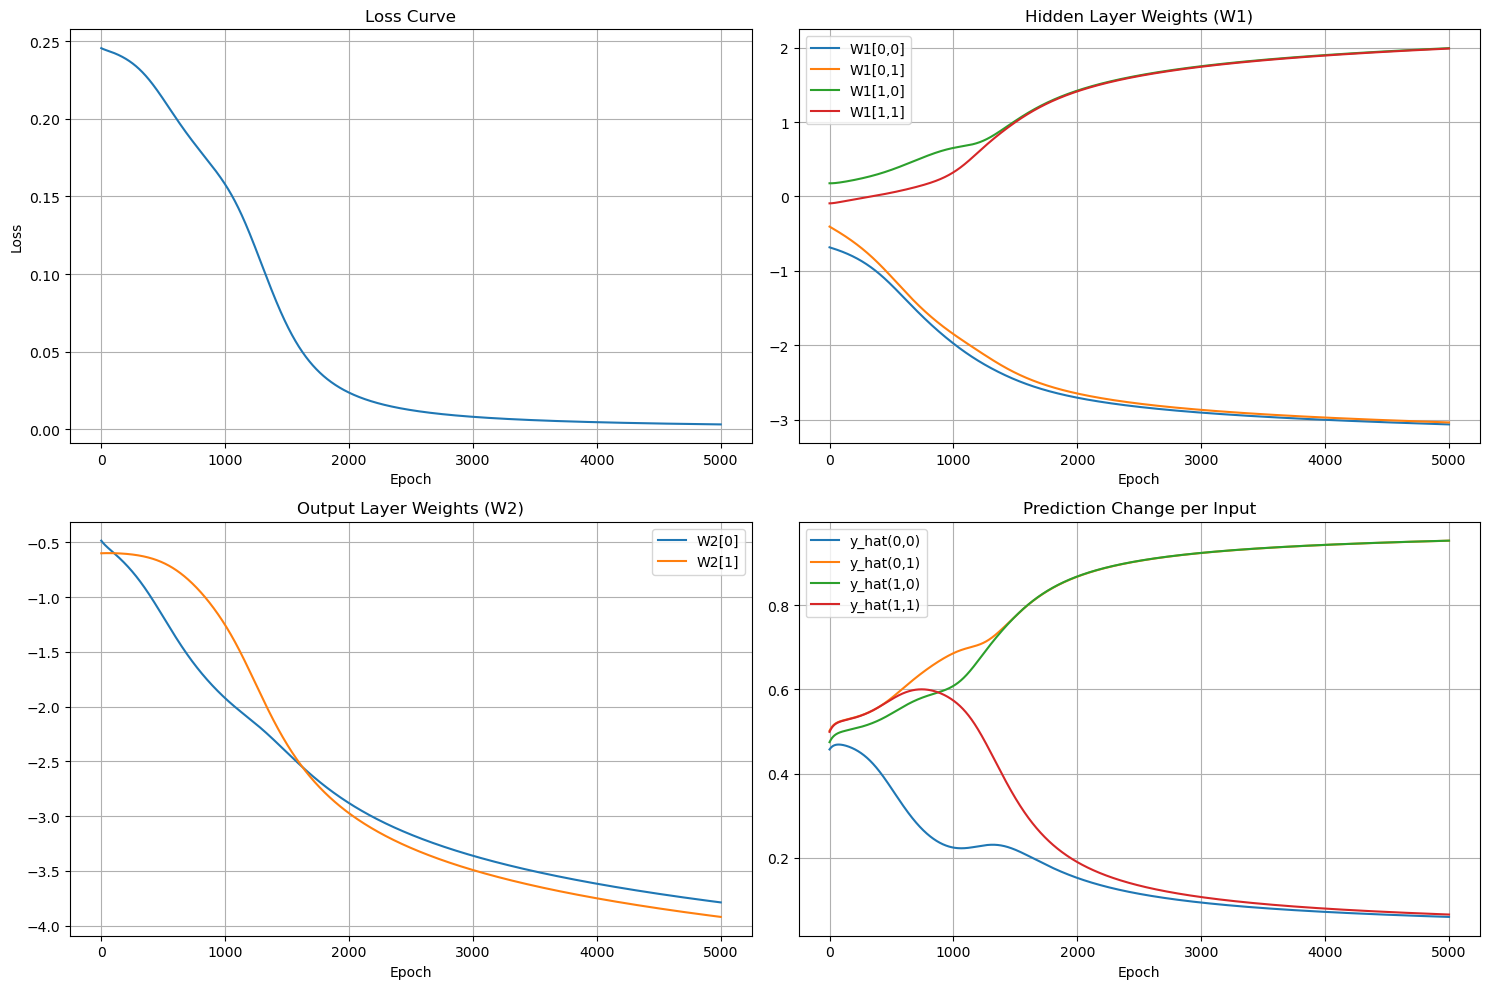

Final Output:
 tensor([[0.0598],
        [0.9528],
        [0.9530],
        [0.0654]], grad_fn=<SigmoidBackward0>)
Final Hidden:
 tensor([[ 0.8825, -0.9937],
        [-0.9291, -0.7129],
        [-0.9326, -0.7102],
        [-0.9998,  0.8004]], grad_fn=<TanhBackward0>)
Final Loss: 0.003073199186474085


In [12]:
# 그래프에 격자추가

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# ====== 1. 데이터 ======
X = torch.tensor([[0.,0.],
                  [0.,1.],
                  [1.,0.],
                  [1.,1.]], dtype=torch.float32)
y = torch.tensor([[0.],
                  [1.],
                  [1.],
                  [0.]], dtype=torch.float32)


# ====== 2. 모델 ======
class XORNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 2)
        self.act1 = nn.Tanh()
        self.fc2 = nn.Linear(2, 1)
        self.act2 = nn.Sigmoid()

    def forward(self, x):
        h = self.act1(self.fc1(x))
        out = self.act2(self.fc2(h))
        return out, h

model = XORNet()


# ====== 3. 손실 & 옵티마이저 ======
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

# ====== 4. 기록 ======
epochs = 5000
log_loss = []
log_W1 = []
log_W2 = []
log_yhat = []
log_hidden = []

# ====== 5. 학습 ======
for epoch in range(epochs):

    y_hat, hidden = model(X)
    loss = criterion(y_hat, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # 기록 (매 epoch 저장)
    log_loss.append(loss.item())
    log_W1.append(model.fc1.weight.data.clone().numpy())
    log_W2.append(model.fc2.weight.data.clone().numpy())
    log_yhat.append(y_hat.data.clone().numpy())
    log_hidden.append(hidden.data.clone().numpy())


# ====== 6. 시각화 ======
plt.figure(figsize=(15, 10))

# ---- (1) Loss 그래프 ----
plt.subplot(2, 2, 1)
plt.plot(log_loss)
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)   # ← 격자 추가

# ---- (2) W1 변화 ----
W1_arr = torch.tensor(log_W1).numpy()
plt.subplot(2, 2, 2)
plt.plot(W1_arr[:,0,0], label="W1[0,0]")
plt.plot(W1_arr[:,0,1], label="W1[0,1]")
plt.plot(W1_arr[:,1,0], label="W1[1,0]")
plt.plot(W1_arr[:,1,1], label="W1[1,1]")
plt.title("Hidden Layer Weights (W1)")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True)   # ← 격자 추가

# ---- (3) W2 변화 ----
W2_arr = torch.tensor(log_W2).numpy()
plt.subplot(2, 2, 3)
plt.plot(W2_arr[:,0,0], label="W2[0]")
plt.plot(W2_arr[:,0,1], label="W2[1]")
plt.title("Output Layer Weights (W2)")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True)   # ← 격자 추가

# ---- (4) 출력값 변화 ----
yhat_arr = torch.tensor(log_yhat).numpy()
plt.subplot(2, 2, 4)
plt.plot(yhat_arr[:,0,0], label="y_hat(0,0)")
plt.plot(yhat_arr[:,1,0], label="y_hat(0,1)")
plt.plot(yhat_arr[:,2,0], label="y_hat(1,0)")
plt.plot(yhat_arr[:,3,0], label="y_hat(1,1)")
plt.title("Prediction Change per Input")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True)   # ← 격자 추가

plt.tight_layout()
plt.show()


# ====== 7. 최종 결과 ======
final_y, final_h = model(X)
print("Final Output:\n", final_y)
print("Final Hidden:\n", final_h)
print("Final Loss:", criterion(final_y, y).item())


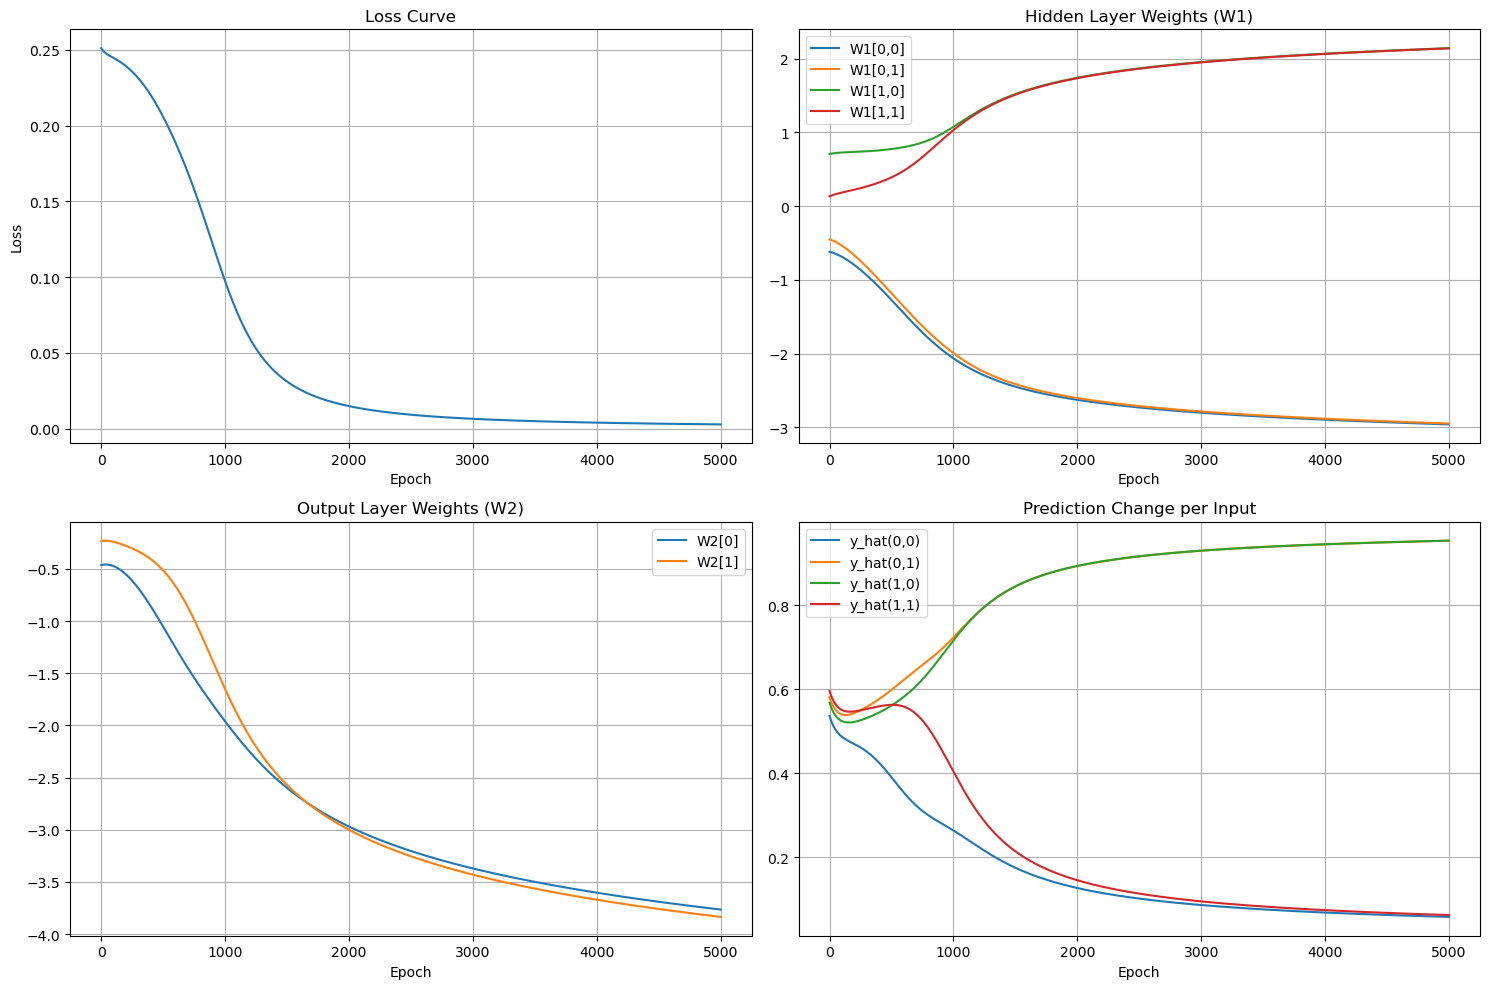

Final Output:
 tensor([[0.0580],
        [0.9544],
        [0.9545],
        [0.0624]], grad_fn=<SigmoidBackward0>)
Final Hidden:
 tensor([[ 0.8721, -0.9961],
        [-0.9226, -0.7542],
        [-0.9244, -0.7528],
        [-0.9998,  0.8214]], grad_fn=<TanhBackward0>)
Final Loss: 0.0028527197428047657


In [13]:
# 그래프에 격자추가

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# ====== 1. 데이터 ======
X = torch.tensor([[0.,0.],
                  [0.,1.],
                  [1.,0.],
                  [1.,1.]], dtype=torch.float32)
y = torch.tensor([[0.],
                  [1.],
                  [1.],
                  [0.]], dtype=torch.float32)


# ====== 2. 모델 ======
class XORNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 2)
        self.act1 = nn.Tanh()
        self.fc2 = nn.Linear(2, 1)
        self.act2 = nn.Sigmoid()

    def forward(self, x):
        h = self.act1(self.fc1(x))
        out = self.act2(self.fc2(h))
        return out, h

model = XORNet()


# ====== 3. 손실 & 옵티마이저 ======
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

# ====== 4. 기록 ======
epochs = 5000
log_loss = []
log_W1 = []
log_W2 = []
log_yhat = []
log_hidden = []

# ====== 5. 학습 ======
for epoch in range(epochs):

    y_hat, hidden = model(X)
    loss = criterion(y_hat, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # 기록 (매 epoch 저장)
    log_loss.append(loss.item())
    log_W1.append(model.fc1.weight.data.clone().numpy())
    log_W2.append(model.fc2.weight.data.clone().numpy())
    log_yhat.append(y_hat.data.clone().numpy())
    log_hidden.append(hidden.data.clone().numpy())


# ====== 6. 시각화 ======
plt.figure(figsize=(15, 10))

# ---- (1) Loss 그래프 ----
plt.subplot(2, 2, 1)
plt.plot(log_loss)
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)   # ← 격자 추가

# ---- (2) W1 변화 ----
W1_arr = torch.tensor(log_W1).numpy()
plt.subplot(2, 2, 2)
plt.plot(W1_arr[:,0,0], label="W1[0,0]")
plt.plot(W1_arr[:,0,1], label="W1[0,1]")
plt.plot(W1_arr[:,1,0], label="W1[1,0]")
plt.plot(W1_arr[:,1,1], label="W1[1,1]")
plt.title("Hidden Layer Weights (W1)")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True)   # ← 격자 추가

# ---- (3) W2 변화 ----
W2_arr = torch.tensor(log_W2).numpy()
plt.subplot(2, 2, 3)
plt.plot(W2_arr[:,0,0], label="W2[0]")
plt.plot(W2_arr[:,0,1], label="W2[1]")
plt.title("Output Layer Weights (W2)")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True)   # ← 격자 추가

# ---- (4) 출력값 변화 ----
yhat_arr = torch.tensor(log_yhat).numpy()
plt.subplot(2, 2, 4)
plt.plot(yhat_arr[:,0,0], label="y_hat(0,0)")
plt.plot(yhat_arr[:,1,0], label="y_hat(0,1)")
plt.plot(yhat_arr[:,2,0], label="y_hat(1,0)")
plt.plot(yhat_arr[:,3,0], label="y_hat(1,1)")
plt.title("Prediction Change per Input")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True)   # ← 격자 추가

plt.tight_layout()
plt.show()


# ====== 7. 최종 결과 ======
final_y, final_h = model(X)
print("Final Output:\n", final_y)
print("Final Hidden:\n", final_h)
print("Final Loss:", criterion(final_y, y).item())


# 초기 가중치 고정한채 학습하면 손실함수가 고정되어 가중치 변화추이가 동일하다

/var/folders/_7/bq432lbj2zvb32y8mzswjpy00000gn/T/ipykernel_3337/3557681870.py:82: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  W1_arr = torch.tensor(log_W1).numpy()


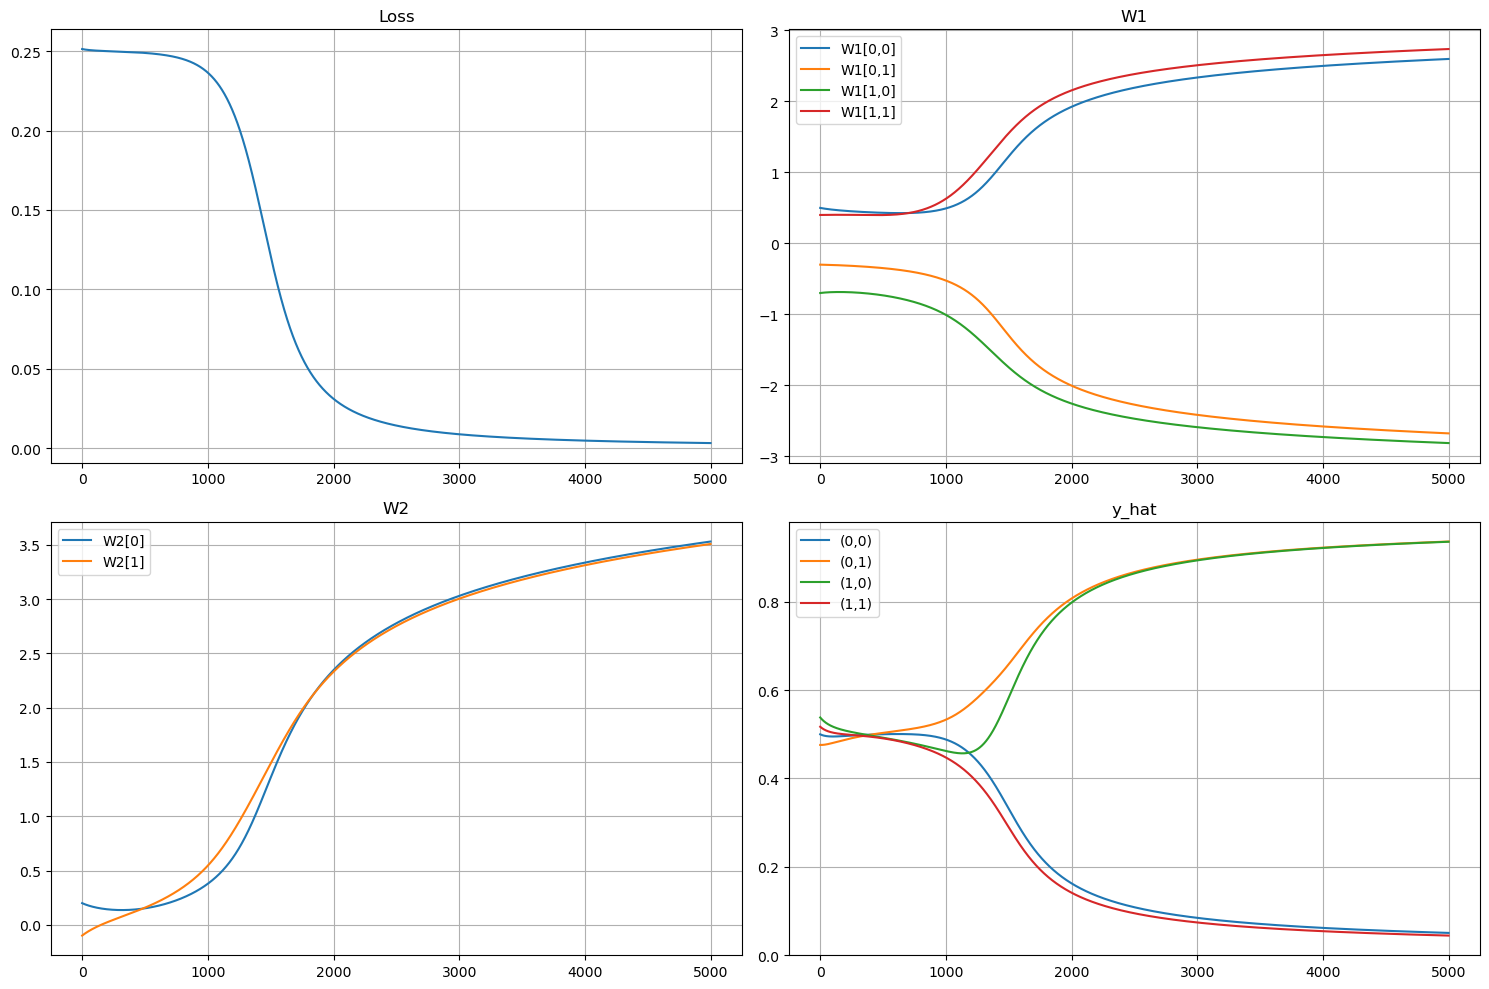

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(42)  # 랜덤 시드 고정

# ====== 1. 데이터 ======
X = torch.tensor([[0.,0.],
                  [0.,1.],
                  [1.,0.],
                  [1.,1.]], dtype=torch.float32)
y = torch.tensor([[0.],
                  [1.],
                  [1.],
                  [0.]], dtype=torch.float32)


# ====== 2. 모델 ======
class XORNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 2)
        self.act1 = nn.Tanh()
        self.fc2 = nn.Linear(2, 1)
        self.act2 = nn.Sigmoid()

        # ---- 초기 가중치 강제 설정 ----
        with torch.no_grad():
            self.fc1.weight.copy_(torch.tensor([[0.5, -0.3],
                                                [-0.7, 0.4]]))
            self.fc1.bias.copy_(torch.tensor([0.0, 0.0]))

            self.fc2.weight.copy_(torch.tensor([[0.2, -0.1]]))
            self.fc2.bias.copy_(torch.tensor([0.0]))

    def forward(self, x):
        h = self.act1(self.fc1(x))
        out = self.act2(self.fc2(h))
        return out, h

model = XORNet()


# ====== 3. 손실 & 옵티마이저 ======
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

# ====== 4. 기록 ======
epochs = 5000
log_loss = []
log_W1 = []
log_W2 = []
log_yhat = []
log_hidden = []


# ====== 5. 학습 ======
for epoch in range(epochs):

    y_hat, hidden = model(X)
    loss = criterion(y_hat, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    log_loss.append(loss.item())
    log_W1.append(model.fc1.weight.data.clone().numpy())
    log_W2.append(model.fc2.weight.data.clone().numpy())
    log_yhat.append(y_hat.data.clone().numpy())
    log_hidden.append(hidden.data.clone().numpy())


# ====== 6. 그래프 출력 ======
plt.figure(figsize=(15, 10))

plt.subplot(2,2,1)
plt.plot(log_loss); plt.grid(True); plt.title("Loss")

plt.subplot(2,2,2)
W1_arr = torch.tensor(log_W1).numpy()
plt.plot(W1_arr[:,0,0], label="W1[0,0]")
plt.plot(W1_arr[:,0,1], label="W1[0,1]")
plt.plot(W1_arr[:,1,0], label="W1[1,0]")
plt.plot(W1_arr[:,1,1], label="W1[1,1]")
plt.grid(True); plt.title("W1"); plt.legend()

plt.subplot(2,2,3)
W2_arr = torch.tensor(log_W2).numpy()
plt.plot(W2_arr[:,0,0], label="W2[0]")
plt.plot(W2_arr[:,0,1], label="W2[1]")
plt.grid(True); plt.title("W2"); plt.legend()

plt.subplot(2,2,4)
yh = torch.tensor(log_yhat).numpy()
plt.plot(yh[:,0,0], label="(0,0)")
plt.plot(yh[:,1,0], label="(0,1)")
plt.plot(yh[:,2,0], label="(1,0)")
plt.plot(yh[:,3,0], label="(1,1)")
plt.grid(True); plt.title("y_hat"); plt.legend()

plt.tight_layout()
plt.show()


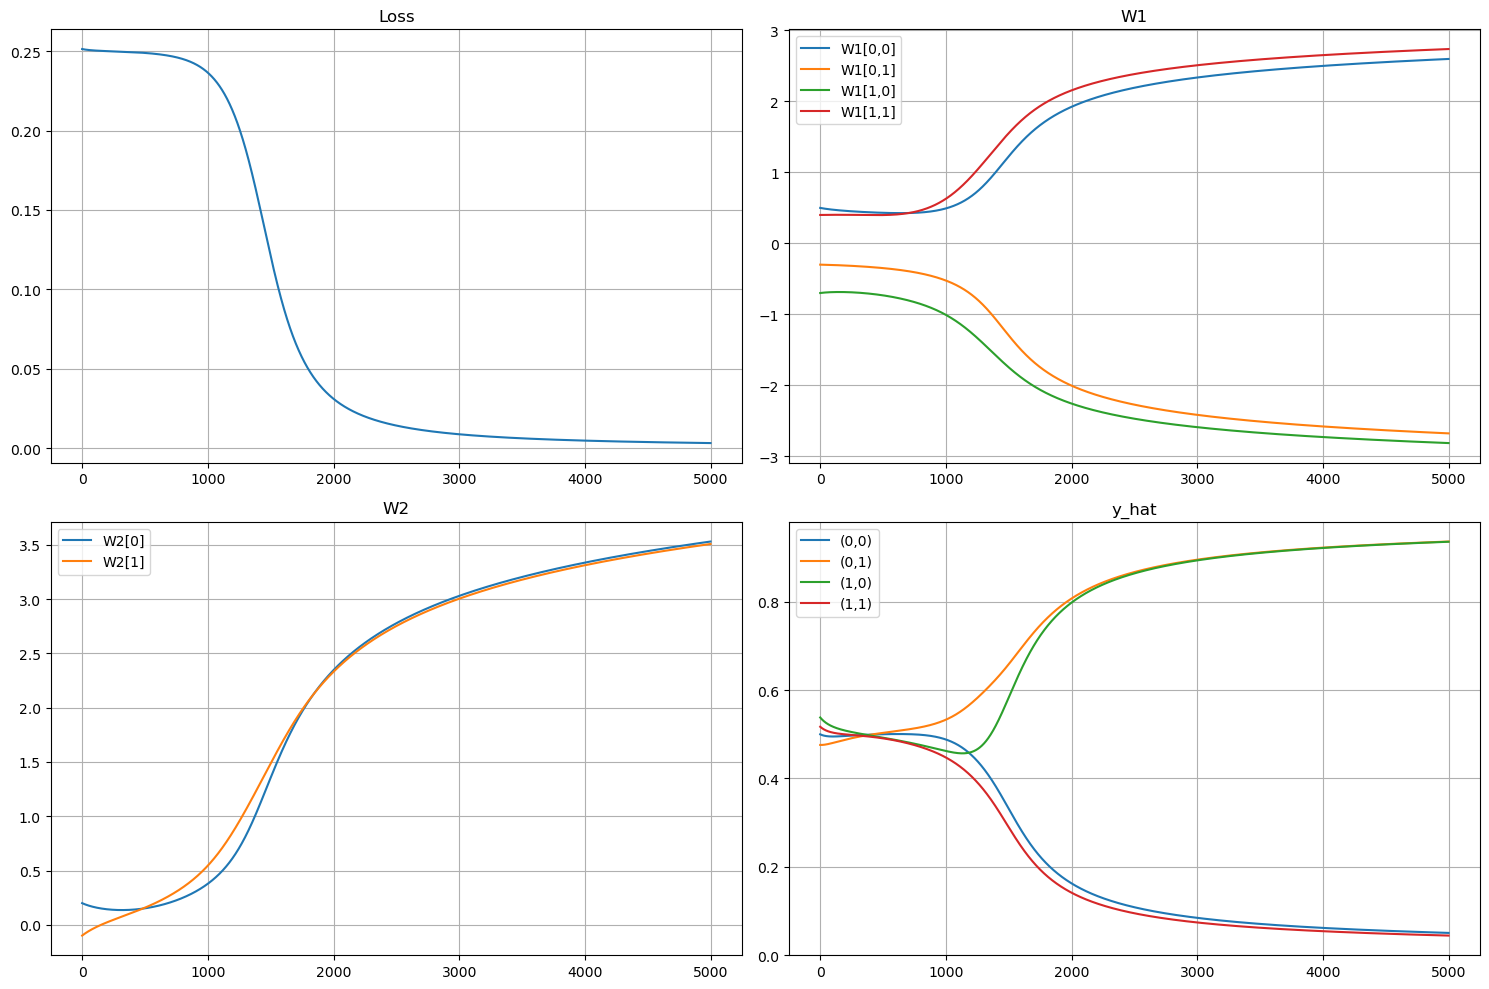

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(42)  # 랜덤 시드 고정

# ====== 1. 데이터 ======
X = torch.tensor([[0.,0.],
                  [0.,1.],
                  [1.,0.],
                  [1.,1.]], dtype=torch.float32)
y = torch.tensor([[0.],
                  [1.],
                  [1.],
                  [0.]], dtype=torch.float32)


# ====== 2. 모델 ======
class XORNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 2)
        self.act1 = nn.Tanh()
        self.fc2 = nn.Linear(2, 1)
        self.act2 = nn.Sigmoid()

        # ---- 초기 가중치 강제 설정 ----
        with torch.no_grad():
            self.fc1.weight.copy_(torch.tensor([[0.5, -0.3],
                                                [-0.7, 0.4]]))
            self.fc1.bias.copy_(torch.tensor([0.0, 0.0]))

            self.fc2.weight.copy_(torch.tensor([[0.2, -0.1]]))
            self.fc2.bias.copy_(torch.tensor([0.0]))

    def forward(self, x):
        h = self.act1(self.fc1(x))
        out = self.act2(self.fc2(h))
        return out, h

model = XORNet()


# ====== 3. 손실 & 옵티마이저 ======
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

# ====== 4. 기록 ======
epochs = 5000
log_loss = []
log_W1 = []
log_W2 = []
log_yhat = []
log_hidden = []


# ====== 5. 학습 ======
for epoch in range(epochs):

    y_hat, hidden = model(X)
    loss = criterion(y_hat, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    log_loss.append(loss.item())
    log_W1.append(model.fc1.weight.data.clone().numpy())
    log_W2.append(model.fc2.weight.data.clone().numpy())
    log_yhat.append(y_hat.data.clone().numpy())
    log_hidden.append(hidden.data.clone().numpy())


# ====== 6. 그래프 출력 ======
plt.figure(figsize=(15, 10))

plt.subplot(2,2,1)
plt.plot(log_loss); plt.grid(True); plt.title("Loss")

plt.subplot(2,2,2)
W1_arr = torch.tensor(log_W1).numpy()
plt.plot(W1_arr[:,0,0], label="W1[0,0]")
plt.plot(W1_arr[:,0,1], label="W1[0,1]")
plt.plot(W1_arr[:,1,0], label="W1[1,0]")
plt.plot(W1_arr[:,1,1], label="W1[1,1]")
plt.grid(True); plt.title("W1"); plt.legend()

plt.subplot(2,2,3)
W2_arr = torch.tensor(log_W2).numpy()
plt.plot(W2_arr[:,0,0], label="W2[0]")
plt.plot(W2_arr[:,0,1], label="W2[1]")
plt.grid(True); plt.title("W2"); plt.legend()

plt.subplot(2,2,4)
yh = torch.tensor(log_yhat).numpy()
plt.plot(yh[:,0,0], label="(0,0)")
plt.plot(yh[:,1,0], label="(0,1)")
plt.plot(yh[:,2,0], label="(1,0)")
plt.plot(yh[:,3,0], label="(1,1)")
plt.grid(True); plt.title("y_hat"); plt.legend()

plt.tight_layout()
plt.show()


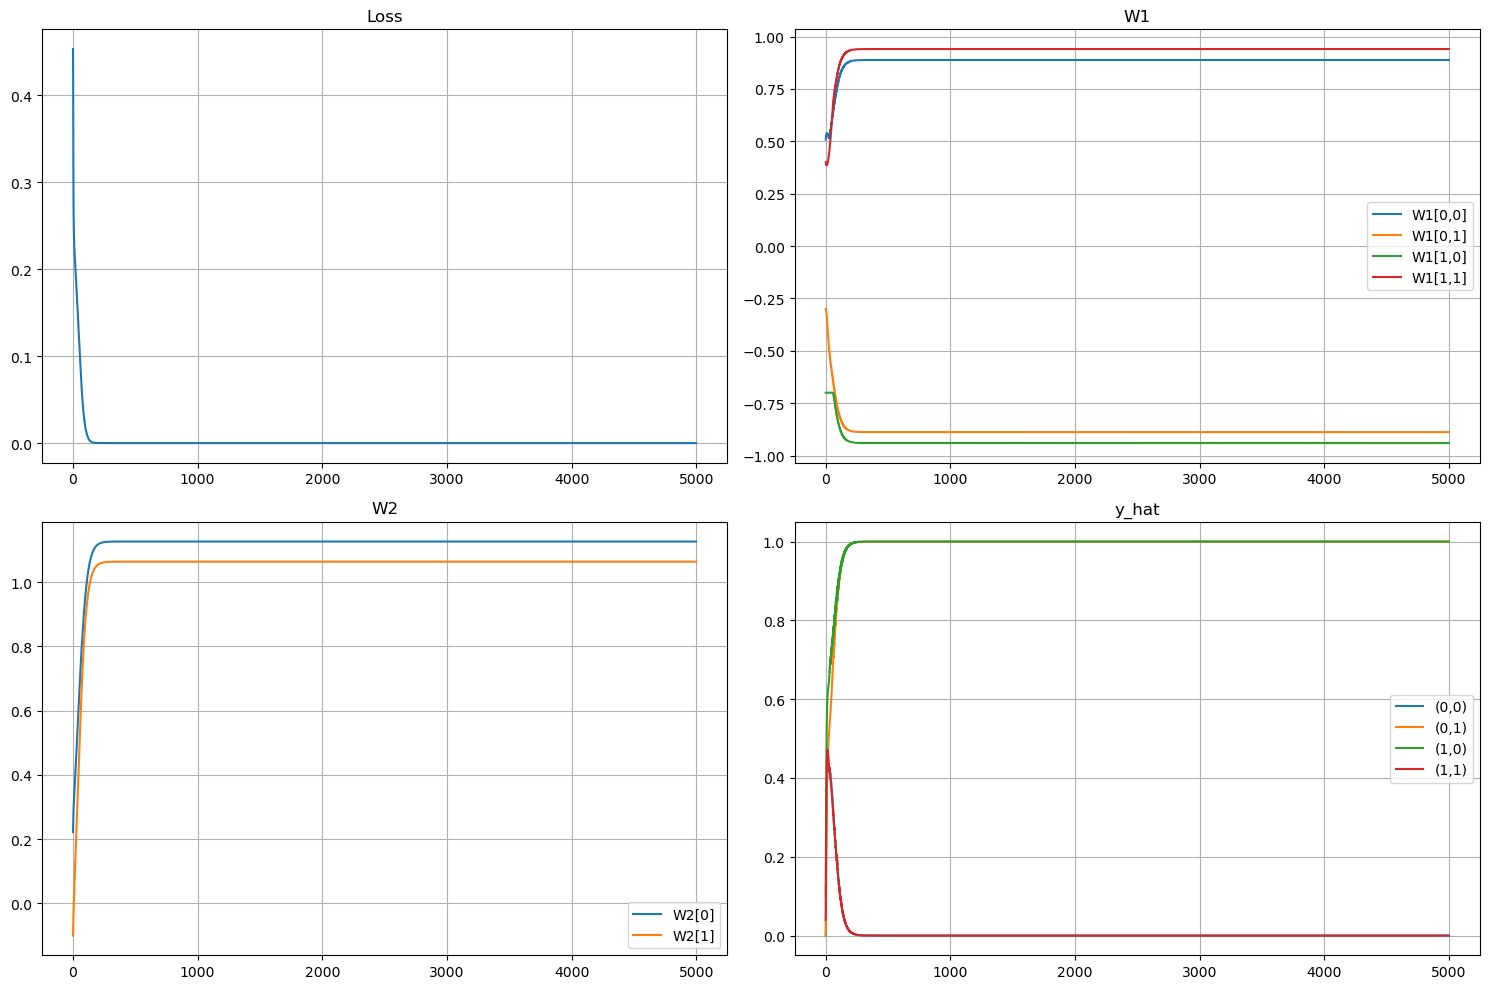

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(42)  # 랜덤 시드 고정

# ====== 1. 데이터 ======
X = torch.tensor([[0.,0.],
                  [0.,1.],
                  [1.,0.],
                  [1.,1.]], dtype=torch.float32)
y = torch.tensor([[0.],
                  [1.],
                  [1.],
                  [0.]], dtype=torch.float32)


# ====== 2. 모델 ======
class XORNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 2)
        self.act1 = nn.ReLU()
        self.fc2 = nn.Linear(2, 1)
        self.act2 = nn.ReLU()

        # ---- 초기 가중치 강제 설정 ----
        with torch.no_grad():
            self.fc1.weight.copy_(torch.tensor([[0.5, -0.3],
                                                [-0.7, 0.4]]))
            self.fc1.bias.copy_(torch.tensor([0.0, 0.0]))

            self.fc2.weight.copy_(torch.tensor([[0.2, -0.1]]))
            self.fc2.bias.copy_(torch.tensor([0.0]))

    def forward(self, x):
        h = self.act1(self.fc1(x))
        out = self.act2(self.fc2(h))
        return out, h

model = XORNet()


# ====== 3. 손실 & 옵티마이저 ======
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

# ====== 4. 기록 ======
epochs = 5000
log_loss = []
log_W1 = []
log_W2 = []
log_yhat = []
log_hidden = []


# ====== 5. 학습 ======
for epoch in range(epochs):

    y_hat, hidden = model(X)
    loss = criterion(y_hat, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    log_loss.append(loss.item())
    log_W1.append(model.fc1.weight.data.clone().numpy())
    log_W2.append(model.fc2.weight.data.clone().numpy())
    log_yhat.append(y_hat.data.clone().numpy())
    log_hidden.append(hidden.data.clone().numpy())


# ====== 6. 그래프 출력 ======
plt.figure(figsize=(15, 10))

plt.subplot(2,2,1)
plt.plot(log_loss); plt.grid(True); plt.title("Loss")

plt.subplot(2,2,2)
W1_arr = torch.tensor(log_W1).numpy()
plt.plot(W1_arr[:,0,0], label="W1[0,0]")
plt.plot(W1_arr[:,0,1], label="W1[0,1]")
plt.plot(W1_arr[:,1,0], label="W1[1,0]")
plt.plot(W1_arr[:,1,1], label="W1[1,1]")
plt.grid(True); plt.title("W1"); plt.legend()

plt.subplot(2,2,3)
W2_arr = torch.tensor(log_W2).numpy()
plt.plot(W2_arr[:,0,0], label="W2[0]")
plt.plot(W2_arr[:,0,1], label="W2[1]")
plt.grid(True); plt.title("W2"); plt.legend()

plt.subplot(2,2,4)
yh = torch.tensor(log_yhat).numpy()
plt.plot(yh[:,0,0], label="(0,0)")
plt.plot(yh[:,1,0], label="(0,1)")
plt.plot(yh[:,2,0], label="(1,0)")
plt.plot(yh[:,3,0], label="(1,1)")
plt.grid(True); plt.title("y_hat"); plt.legend()

plt.tight_layout()
plt.show()


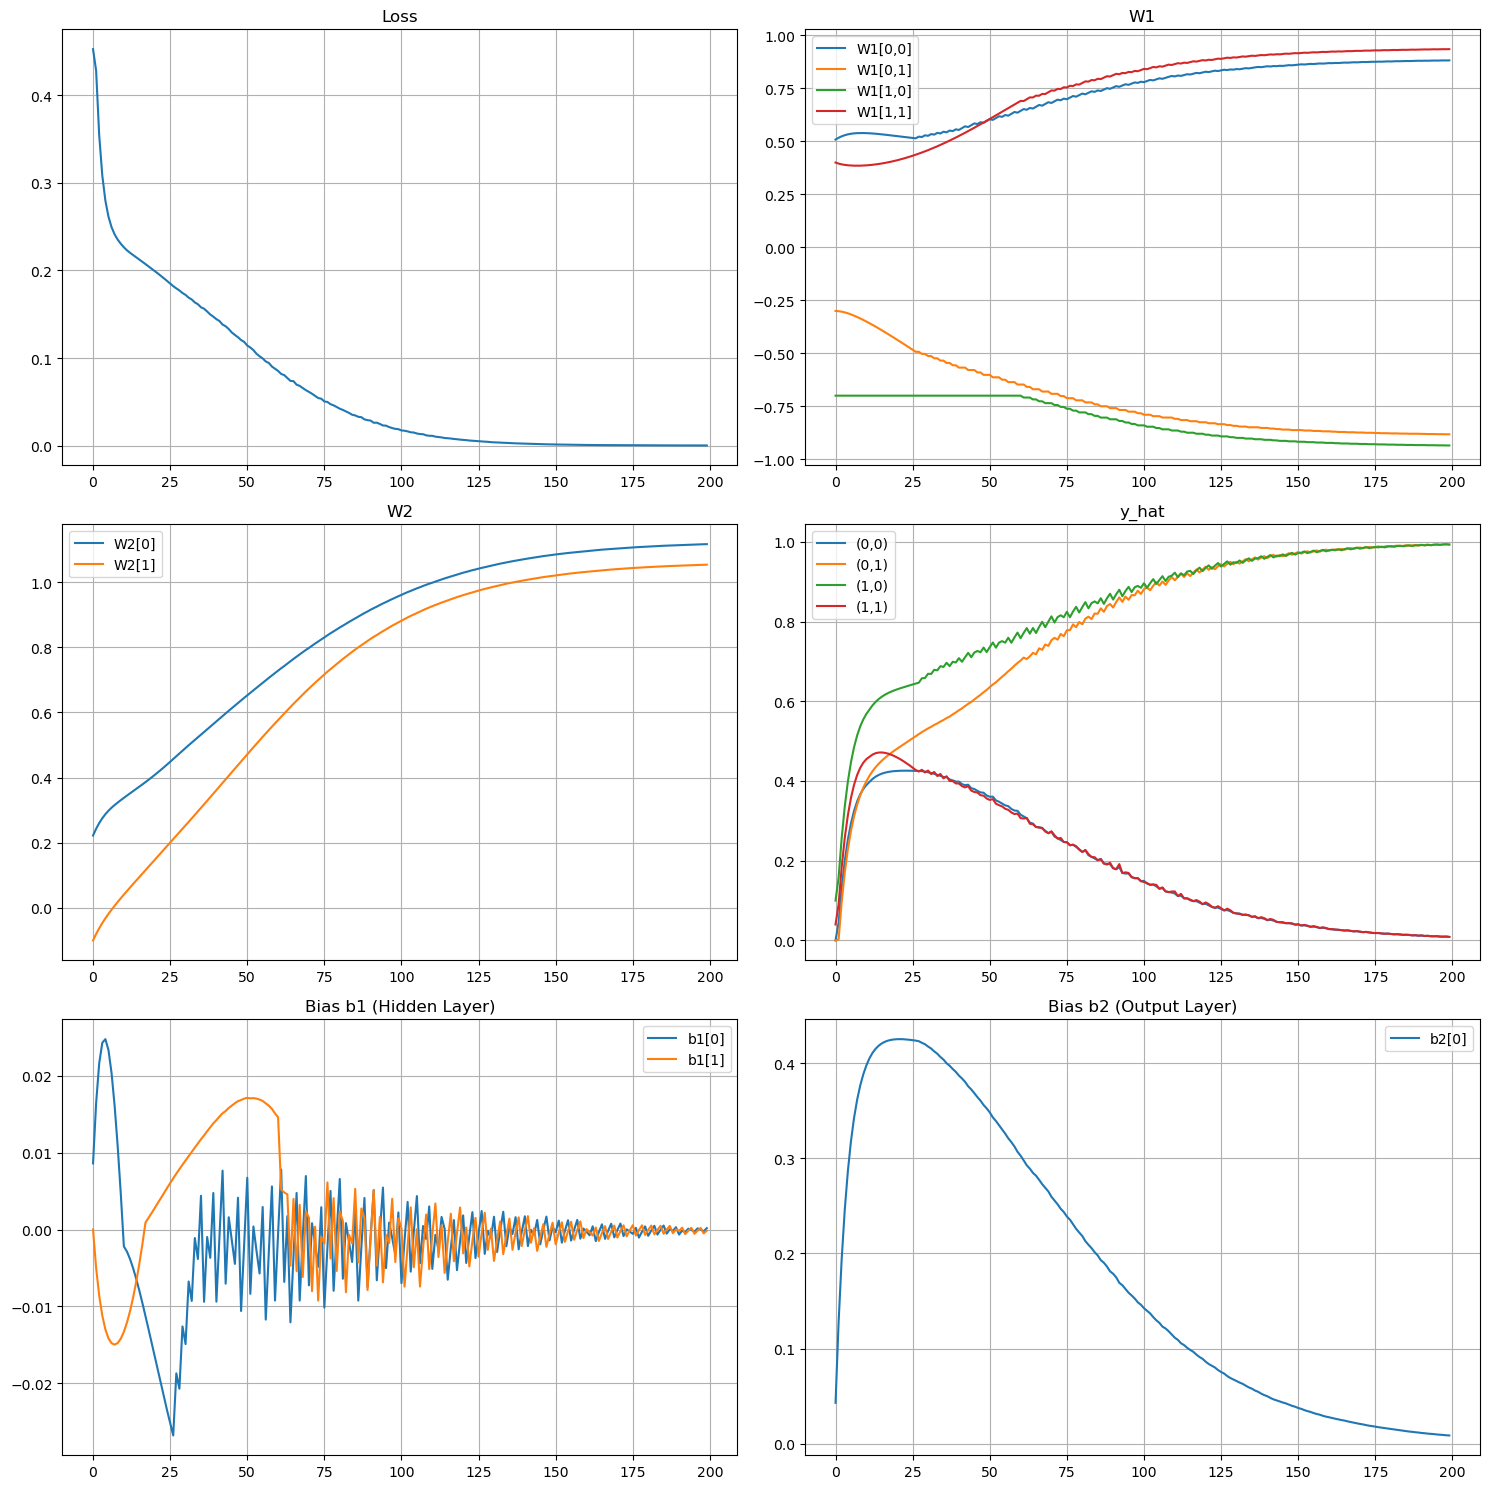


Final Weights and Biases
W1:
 tensor([[ 0.8820, -0.8823],
        [-0.9350,  0.9350]])
b1:
 tensor([ 0.0002, -0.0001])

W2:
 tensor([[1.1168, 1.0538]])
b2:
 tensor([0.0087])

Final Output (y_hat):
 tensor([[0.0089],
        [0.9939],
        [0.9939],
        [0.0087]], grad_fn=<ReluBackward0>)

Final Hidden Output:
 tensor([[1.7490e-04, 0.0000e+00],
        [0.0000e+00, 9.3489e-01],
        [8.8222e-01, 0.0000e+00],
        [0.0000e+00, 0.0000e+00]], grad_fn=<ReluBackward0>)

Final Loss: 5.703161878045648e-05


In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(42)

# ====== 1. 데이터 ======
X = torch.tensor([[0.,0.],
                  [0.,1.],
                  [1.,0.],
                  [1.,1.]], dtype=torch.float32)
y = torch.tensor([[0.],
                  [1.],
                  [1.],
                  [0.]], dtype=torch.float32)

# ====== 2. 모델 ======
class XORNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 2)
        self.act1 = nn.ReLU()
        self.fc2 = nn.Linear(2, 1)
        self.act2 = nn.ReLU()

        with torch.no_grad():
            self.fc1.weight.copy_(torch.tensor([[0.5, -0.3],
                                                [-0.7, 0.4]]))
            self.fc1.bias.copy_(torch.tensor([0.0, 0.0]))

            self.fc2.weight.copy_(torch.tensor([[0.2, -0.1]]))
            self.fc2.bias.copy_(torch.tensor([0.0]))

    def forward(self, x):
        h = self.act1(self.fc1(x))
        out = self.act2(self.fc2(h))
        return out, h

model = XORNet()

# ====== 3. 손실 & 옵티마이저 ======
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

# ====== 4. 기록 ======
epochs = 200
log_loss = []
log_W1 = []
log_W2 = []
log_b1 = []
log_b2 = []
log_yhat = []
log_hidden = []

# ====== 5. 학습 ======
for epoch in range(epochs):
    y_hat, hidden = model(X)
    loss = criterion(y_hat, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    log_loss.append(loss.item())
    log_W1.append(model.fc1.weight.data.clone().numpy())
    log_W2.append(model.fc2.weight.data.clone().numpy())
    log_b1.append(model.fc1.bias.data.clone().numpy())
    log_b2.append(model.fc2.bias.data.clone().numpy())
    log_yhat.append(y_hat.data.clone().numpy())
    log_hidden.append(hidden.data.clone().numpy())


# ====== 6. 그래프 출력 ======
plt.figure(figsize=(15, 15))

# ---- 1. Loss ----
plt.subplot(3, 2, 1)
plt.plot(log_loss); plt.grid(True)
plt.title("Loss")

# ---- 2. W1 ----
plt.subplot(3, 2, 2)
W1_arr = torch.tensor(log_W1).numpy()
plt.plot(W1_arr[:,0,0], label="W1[0,0]")
plt.plot(W1_arr[:,0,1], label="W1[0,1]")
plt.plot(W1_arr[:,1,0], label="W1[1,0]")
plt.plot(W1_arr[:,1,1], label="W1[1,1]")
plt.legend(); plt.grid(True); plt.title("W1")

# ---- 3. W2 ----
plt.subplot(3, 2, 3)
W2_arr = torch.tensor(log_W2).numpy()
plt.plot(W2_arr[:,0,0], label="W2[0]")
plt.plot(W2_arr[:,0,1], label="W2[1]")
plt.legend(); plt.grid(True); plt.title("W2")

# ---- 4. y_hat ----
plt.subplot(3, 2, 4)
yh = torch.tensor(log_yhat).numpy()
plt.plot(yh[:,0,0], label="(0,0)")
plt.plot(yh[:,1,0], label="(0,1)")
plt.plot(yh[:,2,0], label="(1,0)")
plt.plot(yh[:,3,0], label="(1,1)")
plt.legend(); plt.grid(True); plt.title("y_hat")

# ---- 5. b1 ----
plt.subplot(3, 2, 5)
b1_arr = torch.tensor(log_b1).numpy()
plt.plot(b1_arr[:,0], label="b1[0]")
plt.plot(b1_arr[:,1], label="b1[1]")
plt.legend(); plt.grid(True); plt.title("Bias b1 (Hidden Layer)")

# ---- 6. b2 ----
plt.subplot(3, 2, 6)
b2_arr = torch.tensor(log_b2).numpy()
plt.plot(b2_arr[:,0], label="b2[0]")
plt.legend(); plt.grid(True); plt.title("Bias b2 (Output Layer)")

plt.tight_layout()
plt.show()

# ====== 7. 최종 가중치 출력 ======
print("\nFinal Weights and Biases")
print("W1:\n", model.fc1.weight.data)
print("b1:\n", model.fc1.bias.data)
print("\nW2:\n", model.fc2.weight.data)
print("b2:\n", model.fc2.bias.data)

# ====== 8. 최종 출력값 ======
final_y, final_h = model(X)
print("\nFinal Output (y_hat):\n", final_y)
print("\nFinal Hidden Output:\n", final_h)
print("\nFinal Loss:", criterion(final_y, y).item())

'''
학습결과 나온 가중치와 편향으로 신경망 그려서 손계산해봐도 결과 동일함
'''